In [3]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
# Step 2: Load the Dataset

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,224071816,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,260084653,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,253771913,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [5]:
# Step 3: Check Dataset Size (Proof of 10,000+ Rows)

df.shape

(166800, 17)

In [6]:
# Step 4: Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166800 entries, 0 to 166799
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         166800 non-null  str    
 1   County                                             166795 non-null  str    
 2   City                                               166795 non-null  str    
 3   State                                              166800 non-null  str    
 4   Postal Code                                        166795 non-null  float64
 5   Model Year                                         166800 non-null  int64  
 6   Make                                               166800 non-null  str    
 7   Model                                              166800 non-null  str    
 8   Electric Vehicle Type                              166800 non-null  str    
 9   Clea

In [7]:
# Step 5: Statistical Summary

df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,166795.000000,166800.000000,166800.000000,166800.000000,166440.000000,1.668000e+05,1.667950e+05
mean,98173.713750,2020.341793,61.508993,1152.723171,29.178941,2.172420e+08,5.297709e+10
std,2442.584415,3.001465,93.271747,8661.081091,14.853534,7.727458e+07,1.569754e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.790741e+08,5.303301e+10
50%,98122.000000,2021.000000,0.000000,0.000000,33.000000,2.244045e+08,5.303303e+10
75%,98371.000000,2023.000000,84.000000,0.000000,42.000000,2.513421e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [8]:
# Step 6: Check Missing Values

df.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 360
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [9]:
# Step 7: Separate Numerical & Categorical Columns

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

C:\Users\hamza\AppData\Local\Temp\ipykernel_31772\1914668216.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


(Index(['Postal Code', 'Model Year', 'Electric Range', 'Base MSRP',
        'Legislative District', 'DOL Vehicle ID', '2020 Census Tract'],
       dtype='str'),
 Index(['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model',
        'Electric Vehicle Type',
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location',
        'Electric Utility'],
       dtype='str'))

In [10]:
# Step 8: Handle Missing Values (Numerical)

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [11]:
# Step 9: Handle Missing Values (Categorical)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\hamza\AppData\Local\Temp\ipykernel_31772\1738726296.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
# Step 10: Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [13]:
# Step 11: Remove Duplicate Records

df.drop_duplicates(inplace=True)

In [14]:
# Step 12: Outlier Detection (IQR Method)

Q1 = df['Base MSRP'].quantile(0.25)
Q3 = df['Base MSRP'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Base MSRP'] >= Q1 - 1.5 * IQR) & 
        (df['Base MSRP'] <= Q3 + 1.5 * IQR)]

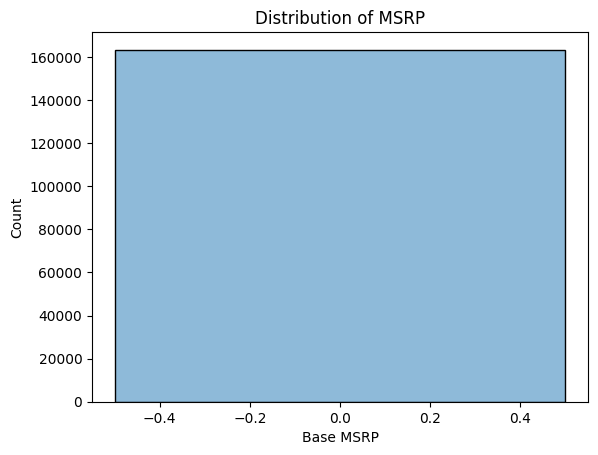

In [15]:
# Step 13: Distribution of MSRP (EDA)

sns.histplot(df['Base MSRP'], kde=True)
plt.title("Distribution of MSRP")
plt.show()

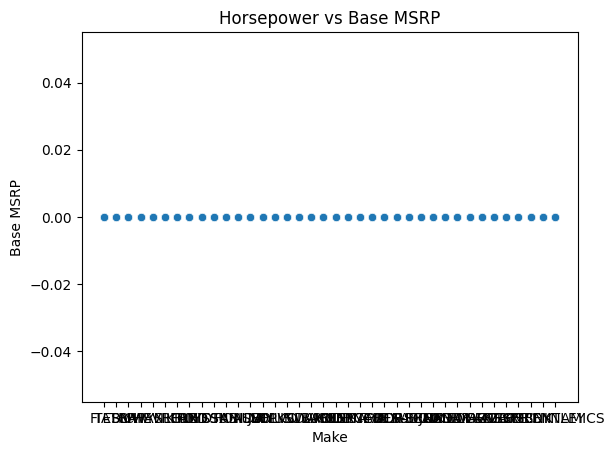

In [16]:
# Step 14: Horsepower vs MSRP

sns.scatterplot(x='Make', y='Base MSRP', data=df)
plt.title("Horsepower vs Base MSRP")
plt.show()

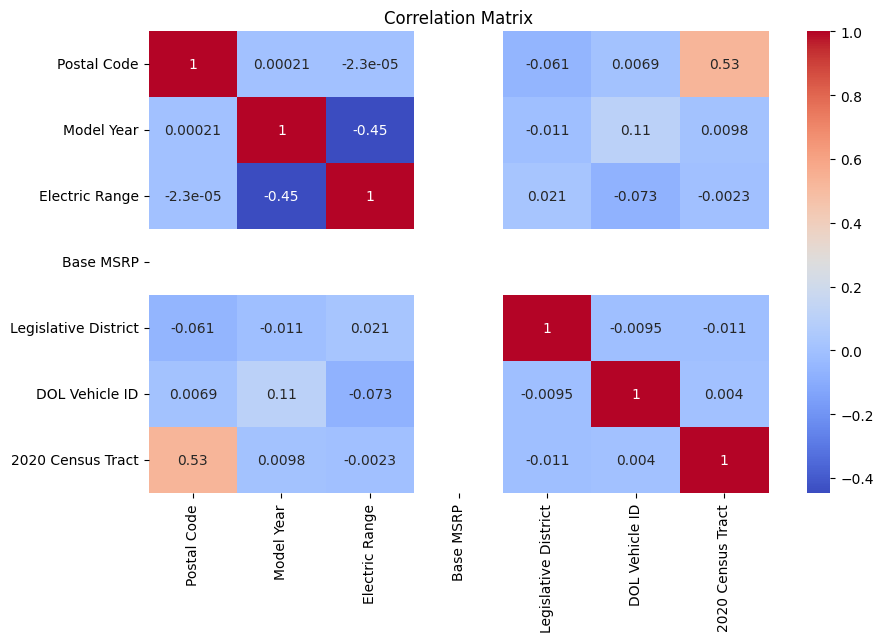

In [17]:
# Step 15: Correlation Heatmap

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [18]:
# Step 16: Encode Categorical Variables

df = df.copy()

# Encode categorical features
df = pd.get_dummies(df, drop_first=True)

In [19]:
# Step 17: Feature Scaling (Standardization)

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [20]:
# Step 18: Split Features and Target

X = df.drop('Base MSRP', axis=1)
y = df['Base MSRP']

X.shape, y.shape

((163437, 11747), (163437,))

In [21]:
# Step 19: Final Cleaned Dataset Preview

df.head()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract,VIN (1-10)_1C4JJXN61P,VIN (1-10)_1C4JJXN62P,VIN (1-10)_1C4JJXN63P,...,Electric Utility_PORTLAND GENERAL ELECTRIC CO,Electric Utility_PUD NO 1 OF CHELAN COUNTY,Electric Utility_PUD NO 1 OF DOUGLAS COUNTY,Electric Utility_PUD NO 1 OF OKANOGAN COUNTY,Electric Utility_PUD NO 1 OF PEND OREILLE COUNTY,Electric Utility_PUD NO 1 OF WHATCOM COUNTY,Electric Utility_PUD NO 2 OF GRANT COUNTY,Electric Utility_PUGET SOUND ENERGY INC,Electric Utility_PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),Electric Utility_PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY
0,0.299966,-2.196573,0.287700,0.0,-1.021510,-2.811352,0.063494,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.139432,-1.173248,1.503695,0.0,-1.829922,0.517687,0.057134,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.048340,0.873403,-0.433288,0.0,-1.223613,0.086591,0.035496,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,-0.067323,0.873403,-0.648509,0.0,-0.549936,0.555685,0.053339,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.059482,-0.149922,2.816539,0.0,0.258475,0.473457,0.035498,False,False,False,...,False,False,False,False,False,False,False,False,True,False
